In [1]:
!pip install -q google-cloud-bigquery
!pip install -q db-dtypes
!pip install -q xgboost
!pip install -q scikit-learn

In [2]:
from google.colab import auth

auth.authenticate_user()

In [3]:
from google.cloud import bigquery

project_id = "clitech-503307"

client = bigquery.Client(project=project_id)

In [4]:
query = """

SELECT *

FROM `clitech-503307.soil_project1.infused_vectors_clean`

"""

df = client.query(query).to_dataframe()

print(df.shape)

df.head()

(8348, 74)


,cell_id,latitude,longitude,A00,A01,A02,A03,A04,A05,A06,...,A61,A62,A63,source,OC_D1,TOTN_D1,BULK_D1,SAND_D1,SILT_D1,CLAY_D1
0,2.0,44.5045,10.51887,-0.334783,-0.009996,-0.146850,0.177153,0.100215,-0.086720,-0.091463,...,0.057071,0.100017,-0.230199,SIMULATED,1.562,1.41,1.41,40.0,40.0,20.0
1,62.0,44.5045,11.27367,-0.209405,0.027680,-0.243460,0.143644,-0.084785,-0.025091,-0.031102,...,-0.044127,-0.120316,0.186362,SIMULATED,1.562,1.41,1.41,40.0,40.0,20.0
2,78.0,44.5045,11.47495,-0.152384,0.043303,-0.146997,0.058810,-0.041108,-0.060421,0.003260,...,-0.194206,-0.134916,0.086732,SIMULATED,1.562,1.41,1.41,40.0,40.0,20.0
3,42.0,44.5045,11.02207,-0.200806,-0.026684,-0.210647,0.130033,0.104798,0.132814,0.061234,...,0.081314,-0.052815,0.151705,SIMULATED,1.562,1.41,1.41,40.0,40.0,20.0
4,19.0,44.5045,10.73273,-0.188821,0.003780,-0.091787,0.140955,0.084548,-0.040506,-0.006418,...,0.079958,0.159926,-0.048946,SIMULATED,1.562,1.41,1.41,40.0,40.0,20.0


In [5]:
df.isnull().sum()

,0
cell_id,0
latitude,0
longitude,0
A00,0
A01,0
...,...
TOTN_D1,0
BULK_D1,0
SAND_D1,0
SILT_D1,0


In [6]:
df = df[df["OC_D1"] > 0]

df = df.dropna(subset=["OC_D1"])

print(df.shape)

(8348, 74)


In [7]:
drop_columns = [

    "cell_id",
    "latitude",
    "longitude",
    "source",

    "OC_D1",
    "TOTN_D1",
    "BULK_D1",
    "SAND_D1",
    "SILT_D1",
    "CLAY_D1"

]

In [8]:
X = df.drop(columns=drop_columns)

y = df["OC_D1"]

print(X.shape)

print(y.shape)

(8348, 64)
(8348,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

In [10]:
print(X_train.shape)

print(X_test.shape)

(6678, 64)
(1670, 64)


In [11]:
from xgboost import XGBRegressor

model = XGBRegressor(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42

)

model.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
predictions = model.predict(X_test)

In [13]:
from sklearn.metrics import (

    mean_absolute_error,

    mean_squared_error,

    r2_score

)

import numpy as np

mae = mean_absolute_error(

    y_test,

    predictions

)

rmse = np.sqrt(

    mean_squared_error(

        y_test,

        predictions

    )

)

r2 = r2_score(

    y_test,

    predictions

)

print(f"MAE  : {mae:.4f}")

print(f"RMSE : {rmse:.4f}")

print(f"R²   : {r2:.4f}")

MAE  : 0.0950
RMSE : 0.1545
R²   : 0.5026


In [14]:
import pandas as pd

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
45,A45,0.067274
41,A41,0.066914
57,A57,0.048703
61,A61,0.042798
47,A47,0.035975
63,A63,0.031348
31,A31,0.027055
29,A29,0.025208
60,A60,0.024728
55,A55,0.022143


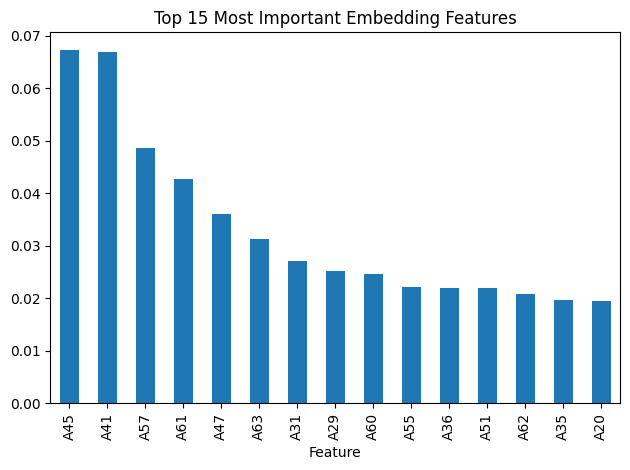

In [15]:
import matplotlib.pyplot as plt

importance.head(15).plot(

    x="Feature",

    y="Importance",

    kind="bar",

    legend=False

)

plt.title("Top 15 Most Important Embedding Features")

plt.tight_layout()

plt.show()

In [16]:
import joblib

joblib.dump(

    model,

    "soc_predictor.pkl"

)

['soc_predictor.pkl']

In [17]:
from google.colab import files

files.download(

    "soc_predictor.pkl"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

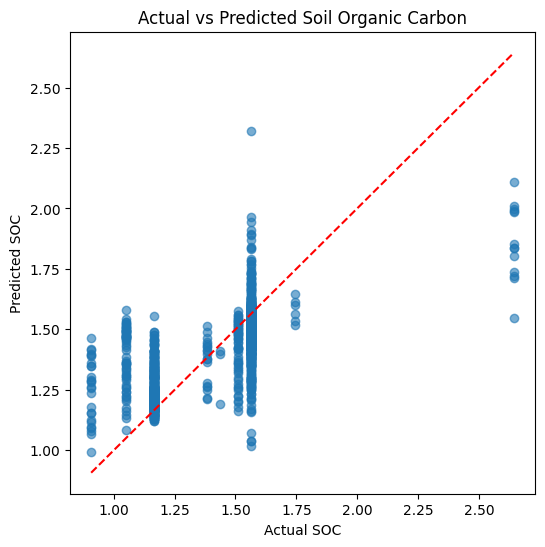

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual SOC")
plt.ylabel("Predicted SOC")
plt.title("Actual vs Predicted Soil Organic Carbon")

plt.show()

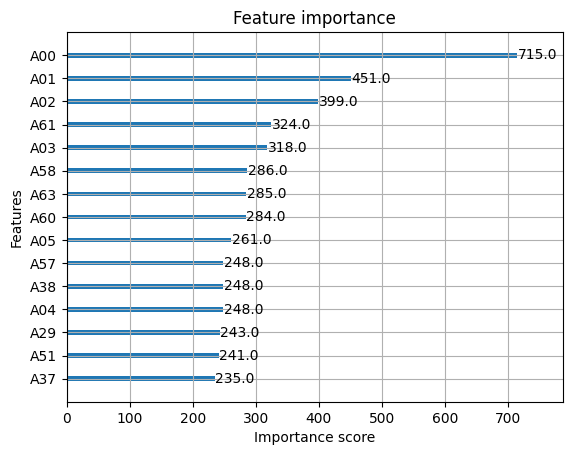

In [19]:
from xgboost import plot_importance

plot_importance(model, max_num_features=15)

plt.show()

In [21]:
joblib.dump(model, "soc_predictor.pkl")
model.save_model("soc_predictor.json")